In [2]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
RUN_ID = 'test'
DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.1
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

In [4]:
model_name = '0509_2355_b4_combo_full_combo_V-dynamic_F-dynamic_399.39min_16h_1500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)
display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 constrained to [0.005, 0.25] Ohm
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.005007,16673.537109,0.013979,0.032191,0.000000,0.000023
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.005007,16673.406250,0.013978,0.032192,0.000023,0.000023
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.005007,16673.279297,0.013976,0.032192,0.000045,0.000023
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.005007,16673.154297,0.013975,0.032193,0.000068,0.000023
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.005007,16673.029297,0.013974,0.032193,0.000090,0.000023
...,...,...,...,...,...,...,...,...,...,...,...,...
209564,124,5.00,0.0,24.891078,0.000000,0.233333,0.248848,2362.500977,0.007377,0.024174,0.272066,0.000497
209565,124,5.00,0.0,24.891078,0.000000,0.231944,0.248900,2334.054932,0.007362,0.024177,0.272563,0.000497
209566,124,5.00,0.0,24.891078,0.000000,0.230556,0.248954,2306.782715,0.007348,0.024180,0.273060,0.000497
209567,124,5.00,0.0,24.891078,0.000000,0.229167,0.249009,2280.636963,0.007335,0.024182,0.273557,0.000497


In [5]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [6]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


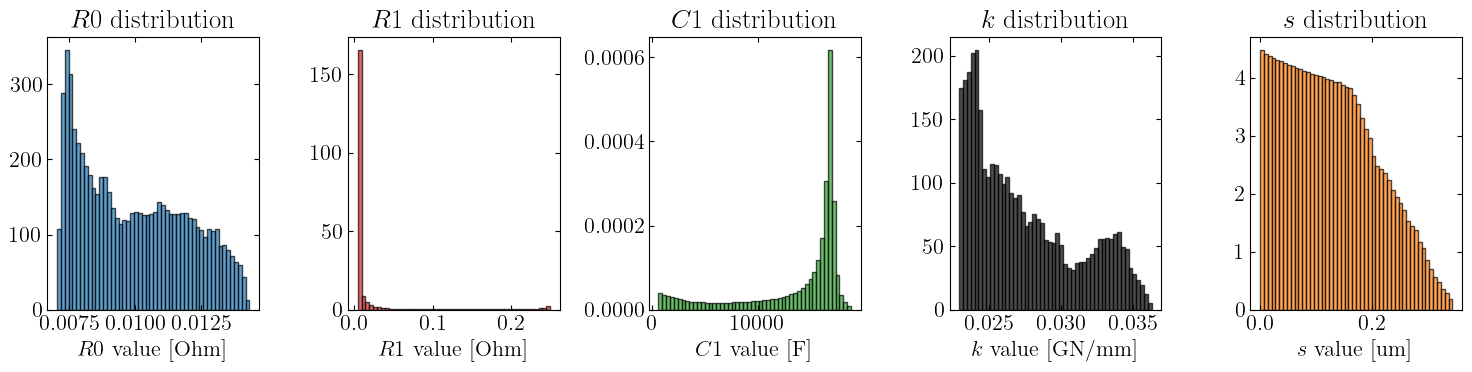

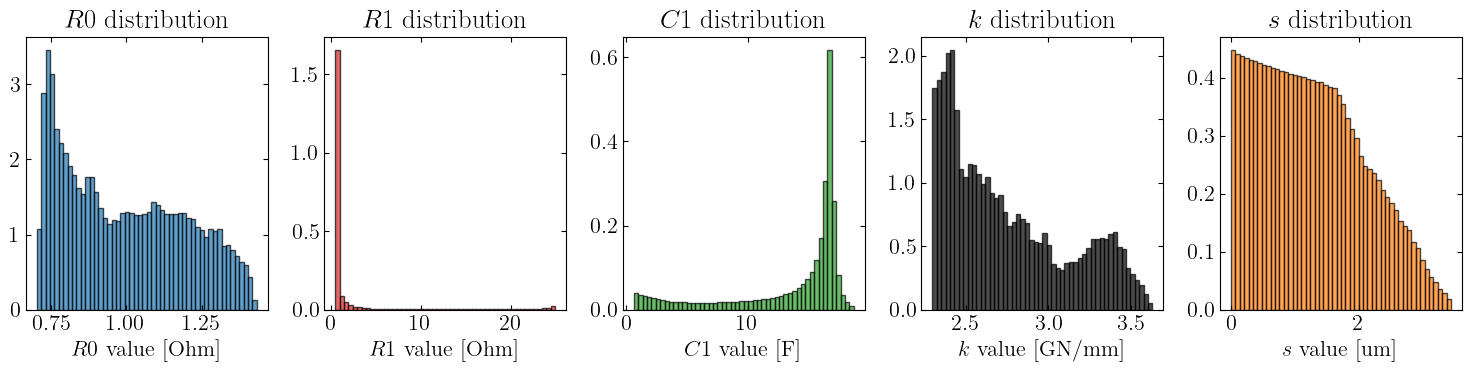

In [7]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [8]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 1e6:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['s'].values  / REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds]

In [9]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 1th data point for symbolic regression, total points: 193820
Using every 1th data point for symbolic regression, total points: 15749


In [10]:
# def print_models(df_model):
#     for i in range(len(df_model)):
#         print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
#         print(f"Equation: {df_model['equation'][i]}\n")

# def print_best_model(model, model_index = None):
#     best = model.get_best()
#     display(Math(f'\\LARGE {model.latex(model_index)}'))
#     display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
#     display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
#     display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
#     print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [11]:
# # Parity plot
# def pareto_plot(model):
#     df_model = model.equations_
#     best = model.get_best()
#     plt.grid(True, which="both", ls="-", linewidth=0.5)
#     plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
#     plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
#     plt.xlabel('Complexity')
#     plt.ylabel('Loss')
#     plt.yscale('log')
#     plt.title('Model Complexity vs Loss')
#     plt.legend()
#     plt.show()

# def parity_plot(element,model, X_test = X_test, Yk_test = Yk_test, YC_test = YC_test, Y_R1_test = YR1_test):
#     if element == 'R1':
#         Y_test = YR1_test
#     elif element == 'k':
#         Y_test = Yk_test
#     elif element == 'C_1':
#         Y_test = YC_test

#     Y_pred = model.predict(X_test)
#     plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
#     plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
#     plt.xlabel(f'Actual ${element}$ [a.u.]')
#     plt.ylabel(f'Predicted ${element}$ [a.u.]')
#     plt.show()

# def save_expressions(df_model, element):
#     df_model.to_csv(f'sr_models/model_{element}.csv', index=False)

# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.04196144
Equation: 0.998337

Model 1: Complexity=4, Loss=0.027726103
Equation: log(x2 + 2.185611)

Model 2: Complexity=5, Loss=0.017968033
Equation: sqrt(cube(x2) + 0.7395534)

Model 3: Complexity=6, Loss=0.015035944
Equation: square(x2 + -0.29774454) + 0.86883295

Model 4: Complexity=7, Loss=0.009949883
Equation: sqrt(square(x2 + -0.3888779)) + 0.7418772

Model 5: Complexity=9, Loss=0.007612872
Equation: sqrt(square(x2 + -0.38512182) / x0) + 0.7688858

Model 6: Complexity=10, Loss=0.007025875
Equation: sqrt(square(x2 + -0.38268253) / sqrt(x0)) + 0.75746834

Model 7: Complexity=12, Loss=0.0063105677
Equation: sqrt((square(x2 + -0.39557597) * 1.4134144) / sqrt(x0)) + 0.7169188

Model 8: Complexity=13, Loss=0.004994579
Equation: sqrt(x2 + sqrt(square(log(x2 - -0.5372882)) / (x0 * 0.18243171)))

Model 9: Complexity=14, Loss=0.0044069756
Equation: sqrt((sqrt(square(log(square(x2 - -0.5362444))) / x0) + x2) + 0.08148999)

Model 10: Complexity=15, Loss=0.0043307

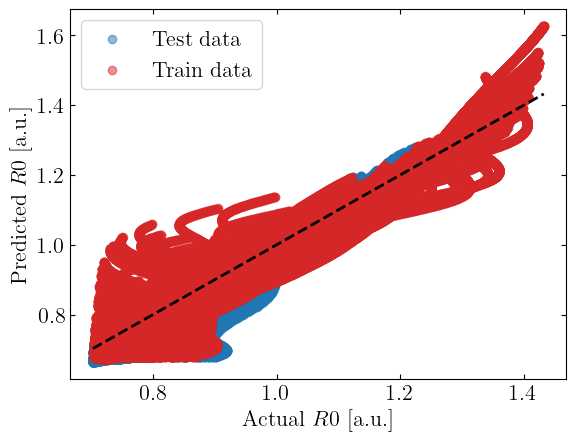

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(x2 + sqrt(log((x2 + 0.53965837)**3)**2/(0.06289294*x0*x1 + x0)))
Loss: 0.00310246
Best model complexity: 18


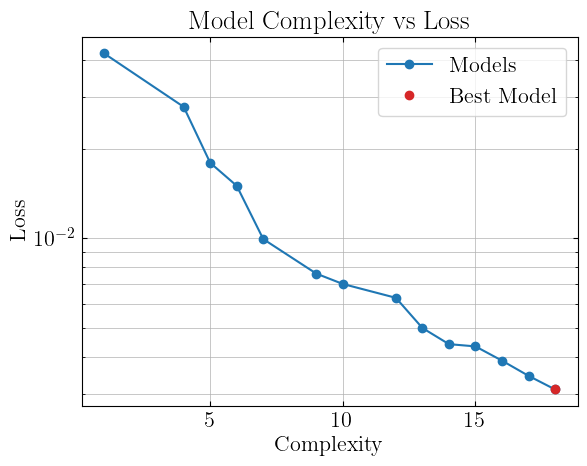

In [12]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}')
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=17.313637
Equation: x0

Model 1: Complexity=3, Loss=10.97969
Equation: 0.70751804 / x2

Model 2: Complexity=4, Loss=10.287259
Equation: sqrt(x0) / x2

Model 3: Complexity=5, Loss=6.464685
Equation: (x0 / x2) - x0

Model 4: Complexity=6, Loss=1.609012
Equation: cube(x0 * (0.1445007 / x2))

Model 5: Complexity=7, Loss=1.5051101
Equation: cube(sqrt(x0 / x2) + -1.6168848)

Model 6: Complexity=8, Loss=1.3408686
Equation: square(((x0 / x2) * 0.30083033) + -1.1648103)

Model 7: Complexity=10, Loss=1.3211404
Equation: square(((x0 / x2) * 0.2965577) + -1.1166818) - -0.15640275

Model 8: Complexity=11, Loss=1.1741264
Equation: cube(log(cube(sqrt(x0 / x2) + -1.9561731) - -2.3412127))

Model 9: Complexity=12, Loss=1.0173068
Equation: square((((x0 + 0.88871735) * 0.14959995) / x2) - 0.9791834) * x0

Model 10: Complexity=14, Loss=0.9480552
Equation: (x0 * square(0.9209185 - (((x0 + 0.90506613) * 0.14510956) / x2))) + 0.29792535

Model 11: Complexity=16, Loss=0.91210395
Eq

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (x0 + 0.7139865)*((x0 + 0.7372111)*0.14368701/(x2 + 0.0069051585) - 1*0.8603078)**2 + 0.18721898
Loss: 0.90732074
Best model complexity: 18


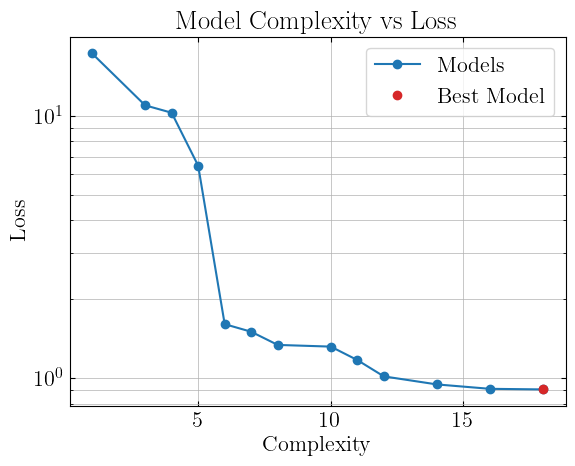

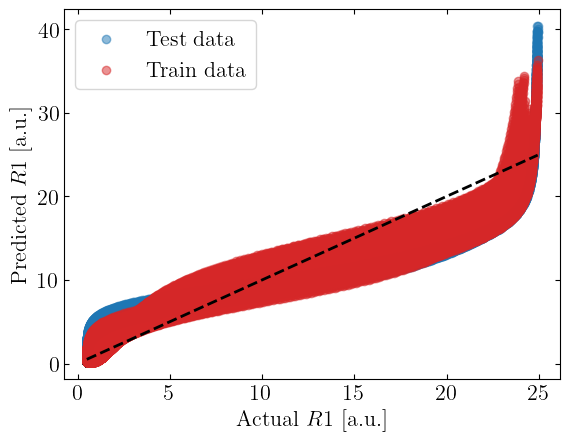

In [13]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}')
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [ ]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}')
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.13627121
Equation: 2.7466676

Model 1: Complexity=4, Loss=0.120665215
Equation: exp(tanh(exp(x1)))

Model 2: Complexity=5, Loss=0.0035249628
Equation: (1.0263093 ^ x1) + 1.3447865

Model 3: Complexity=10, Loss=0.0003152889
Equation: (1.02573 ^ x1) + (cos(1.2374587 ^ x2) - -0.92551196)

Model 4: Complexity=13, Loss=0.00030918312
Equation: ((1.0259744 ^ x1) + cos(tanh((1.6038939 / x2) ^ -0.4682955))) - -0.4894379



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.0259744**x1 + cos(tanh((1.6038939/x2)**(-0.4682955))) - 1*(-0.4894379)
Loss: 0.00030918312
Best model complexity: 13


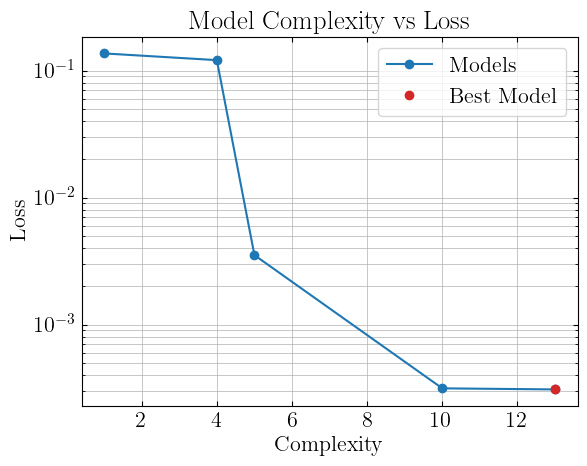

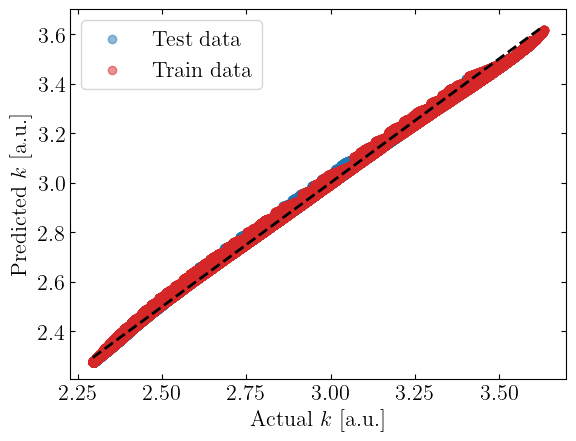

In [ ]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}')
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $s = f_s(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.678785
Equation: 1.2814553

Model 1: Complexity=3, Loss=0.3043298
Equation: x2 ^ -0.40912262

Model 2: Complexity=4, Loss=0.13130774
Equation: square(1.6517318 - x2)

Model 3: Complexity=5, Loss=0.11292238
Equation: square(sinh(x2) - 1.6581976)

Model 4: Complexity=6, Loss=0.10864218
Equation: square((2.4611492 ^ x2) + -2.7046058)

Model 5: Complexity=7, Loss=0.104146644
Equation: square((1.2598184 - tan(x2)) + 0.4530897)

Model 6: Complexity=9, Loss=0.10414664
Equation: square(square(sqrt((1.2598184 - tan(x2)) + 0.4530897)))

Model 7: Complexity=10, Loss=0.10363721
Equation: sqrt(square(cube(sqrt(cos(x2 + 0.46804613)))) * 10.810503)

Model 8: Complexity=15, Loss=0.09753918
Equation: sqrt((square(cube(sinh(cos(x2 * 1.1168222)) * 1.1378472)) - tanh(x1)) - -0.98296106)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(2.17021954714154*sinh(cos(1.1168222*x2))**6 - tanh(x1) + 0.98296106)
Loss: 0.09753918
Best model complexity: 15


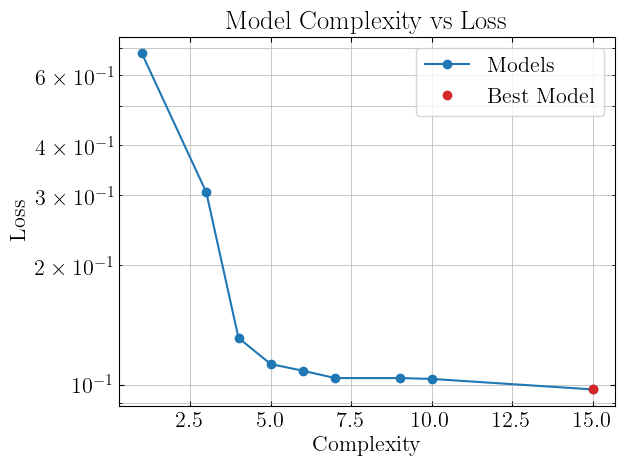

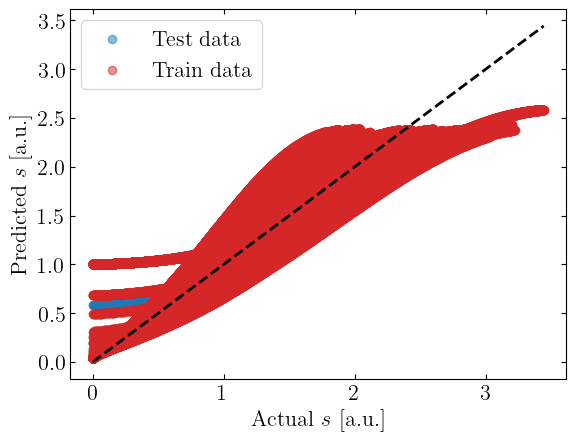

In [ ]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(X_train, Ys_train, model = None,run_id = f's_{RUN_ID}')
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [ ]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [ ]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id].copy()
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id].copy()
    return traj

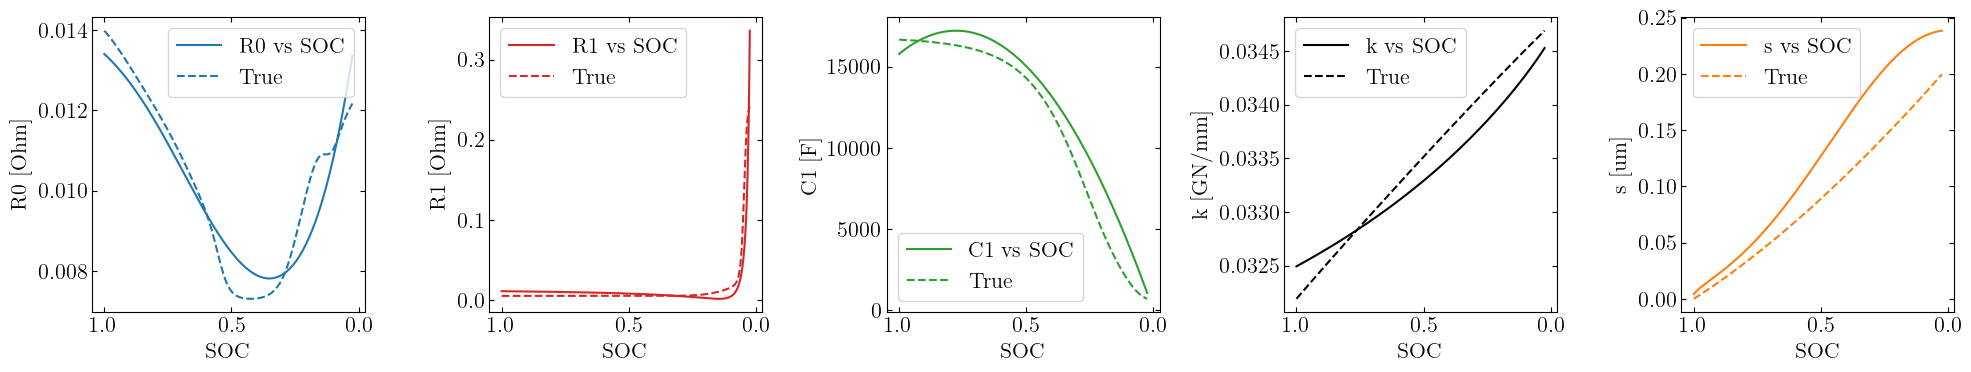

In [ ]:
def plot_soc(models, traj):
    C_fixed = traj['C'].iloc[0]
    u_per_fixed = traj['u_per'].iloc[0]
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        Y_true = traj[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()

traj = get_traj(trajectory_id = 0, test = False)
plot_soc(MODEL_DICT, traj)

In [ ]:
def plot_trajs_SOC(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    f,ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].plot(tr['soc'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
        a.invert_xaxis()
    ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 

    plt.tight_layout()
    plt.savefig('symbolic_traj_test.pdf')

plot_trajs_SOC(test = False, ind = 4)

TypeError: prepare_data() got an unexpected keyword argument 'index'

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required.

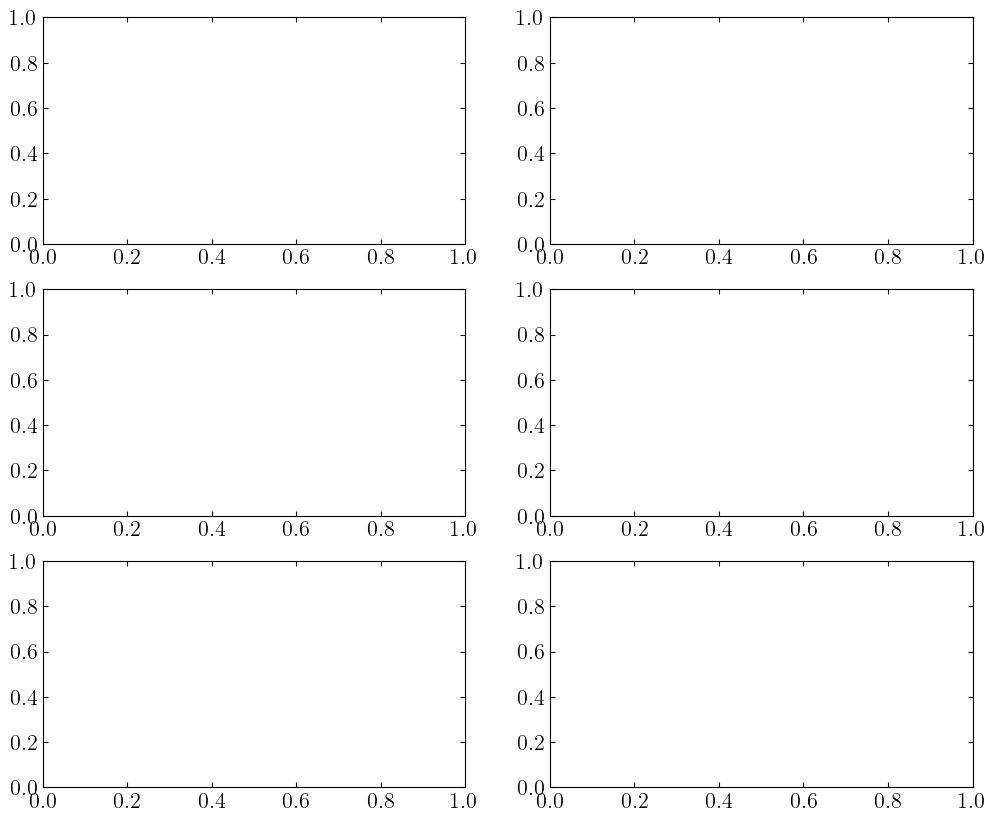

In [ ]:
def plot_trajs_C_d(data = data, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    f,axs = plt.subplots(3,2, figsize=(12,10))
    
    train_index = int(0.8 * N_TRAJS )
    test_index = int(N_TRAJS - train_index)
    if test:
        ind = test_index
    else:
        ind = train_index
    i=0
    k_pred = np.zeros((ind,3)); R1_pred = np.zeros((ind,3)); C1_pred = np.zeros((ind,3))
    k_true = np.zeros((ind,3)); R1_true = np.zeros((ind,3)); C1_true = np.zeros((ind,3))
    X_vals = np.zeros((ind,2))    
    while i < ind:
        tr = prepare_data(data, index = i, test=test)
        X = tr[['C', 'u_per', 'soc']].values
        Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
        YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
        YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
        
        k_pred[i,0] = Yk_pred.mean(); R1_pred[i,0] = YR1_pred.mean(); C1_pred[i,0] = YC_pred.mean()
        k_pred[i,1] = Yk_pred.min(); R1_pred[i,1] = YR1_pred.min(); C1_pred[i,1] = YC_pred.min()
        k_pred[i,2] = Yk_pred.max(); R1_pred[i,2] = YR1_pred.max(); C1_pred[i,2] = YC_pred.max()

        k_true[i,0] = tr['k'].mean() * 100; R1_true[i,0] = tr['R1'].mean() * 1000; C1_true[i,0] = tr['C1'].mean() / 1000
        k_true[i,1] = tr['k'].min() * 100; R1_true[i,1] = tr['R1'].min() * 1000; C1_true[i,1] = tr['C1'].min() / 1000
        k_true[i,2] = tr['k'].max() * 100; R1_true[i,2] = tr['R1'].max() * 1000; C1_true[i,2] = tr['C1'].max() / 1000
        X_vals[i,0] = X[0,0]; X_vals[i,1] = X[0,1]
        i += 1

    for j in range(len(axs[0,:])):
        ax = axs[:,j]
        x = X_vals[:,j]
        ax[0].scatter(x, k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[0].scatter(x, k_true[:,0], label=r'NN $k$',  color=colors[1], alpha=0.7)
        #ax[0].plot(x, k_true[:,1] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].plot(x, k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].fill_between(x, k_true[:,1] * X_vals[:,1], k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.2, label='NN range')
        #ax[1].fill_between(x, R1_true[:,1] , R1_true[:,2], color=colors[1], alpha=0.2, label='NN range')
        #ax[2].fill_between(x, C1_true[:,1], C1_true[:,2], color=colors[1], alpha=0.2, label='NN range')

        ax[1].scatter(x, R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[1].scatter(x, R1_true[:,0], label=r'NN $R_1$',  color=colors[1], alpha=0.7)
        ax[2].scatter(x, C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
        ax[2].scatter(x, C1_true[:,0], label=r'NN $C_1$', color=colors[1], alpha=0.7)
        ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 
        
        ax[0].legend(); ax[1].legend(); ax[2].legend()
    for a in axs[:,0]:
        a.set_xlabel('C-rate [a.u.]')
    for a in axs[:,1]:
        a.set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
    # for tr in test_trajs:
    #     X = tr[['C', 'u_per', 'soc']].values
    #     Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    #     YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    #     YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    #     f,ax = plt.subplots(1,3, figsize=(15,5))
    #     ax[0].plot(tr['C'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    #     ax[0].plot(tr['C'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[1].plot(tr['C'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    #     ax[1].plot(tr['C'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[2].plot(tr['C'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    #     ax[2].plot(tr['C'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    #     for a in ax:
    #         a.set_xlabel('C-rate [a.u.]')
    #         a.legend()
    #         a.invert_xaxis()
        
            
         
    plt.tight_layout()

    plt.show()
    f,ax = plt.subplots(1,3, figsize=(15,4))
    ax[0].scatter(X_vals[:,0],X_vals[:,1],c= k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',cmap = 'Blues')
    ax[0].set_xlabel('C-rate [a.u.]')
    ax[0].set_ylabel(r'$k$ [GN/mm]')
    ax[0].legend()
    ax[1].scatter(X_vals[:,0],X_vals[:,1],c= R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',cmap = 'Greens')
    ax[1].set_xlabel('C-rate [a.u.]')
    ax[1].set_ylabel(r'$R_1$ [m$\Omega$]')
    ax[1].legend()
    ax[2].scatter(X_vals[:,0],X_vals[:,1],c= C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$',cmap = 'Oranges')
    ax[2].set_xlabel('C-rate [a.u.]')
    ax[2].set_ylabel(r'$C_1$ [kF]')
    ax[2].legend()
    plt.tight_layout()

plot_trajs_C_d(test = False)

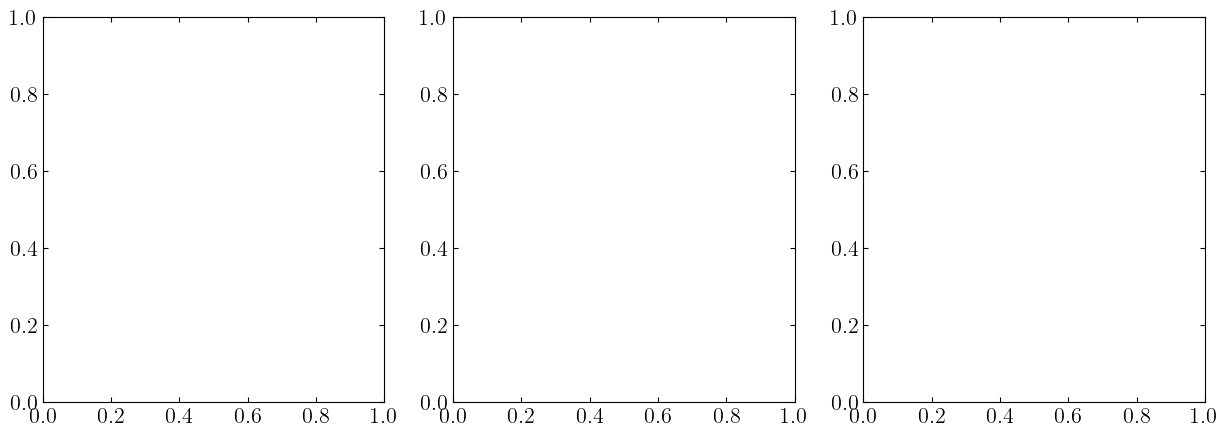

In [ ]:
f,ax = plt.subplots(1,3, figsize=(15,5))

In [ ]:
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')
    save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')